# Kelompok 6

- Rhea Debora Sianturi (5025241089)
- Maleka Ghaniya (5025241189) 
- Mahirah Yasmin Aulia Mawahib (5025241095)
- Nabilah Bunga Sulistia (5025241073)
- Farrell Matthew Lim (5025221258)
- Hilmy Septian Nursyekha (5025221202)

In [178]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objs as go
import numpy as np
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler

# All Features

In [179]:
df = pd.read_csv('./ObesityDataSet_raw_and_data_sinthetic.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [180]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [181]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [182]:
df.columns = df.columns.str.strip()

# Convert True/False boolean columns to 1/0
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# Convert categorical/object columns to numeric codes
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df[cat_cols] = df[cat_cols].apply(lambda col: pd.Categorical(col).codes)

print(df.dtypes)
print(df.head())

Gender                               int8
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight       int8
FAVC                                 int8
FCVC                              float64
NCP                               float64
CAEC                                 int8
SMOKE                                int8
CH2O                              float64
SCC                                  int8
FAF                               float64
TUE                               float64
CALC                                 int8
MTRANS                               int8
NObeyesdad                           int8
dtype: object
   Gender   Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  \
0       0  21.0    1.62    64.0                               1     0   2.0   
1       0  21.0    1.52    56.0                               1     0   3.0   
2       1  23.0    1.80    77.0    

/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/3667412469.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: The palette list has more values (17) than needed (2), which may not be intended.
  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: 
The palette list has fe

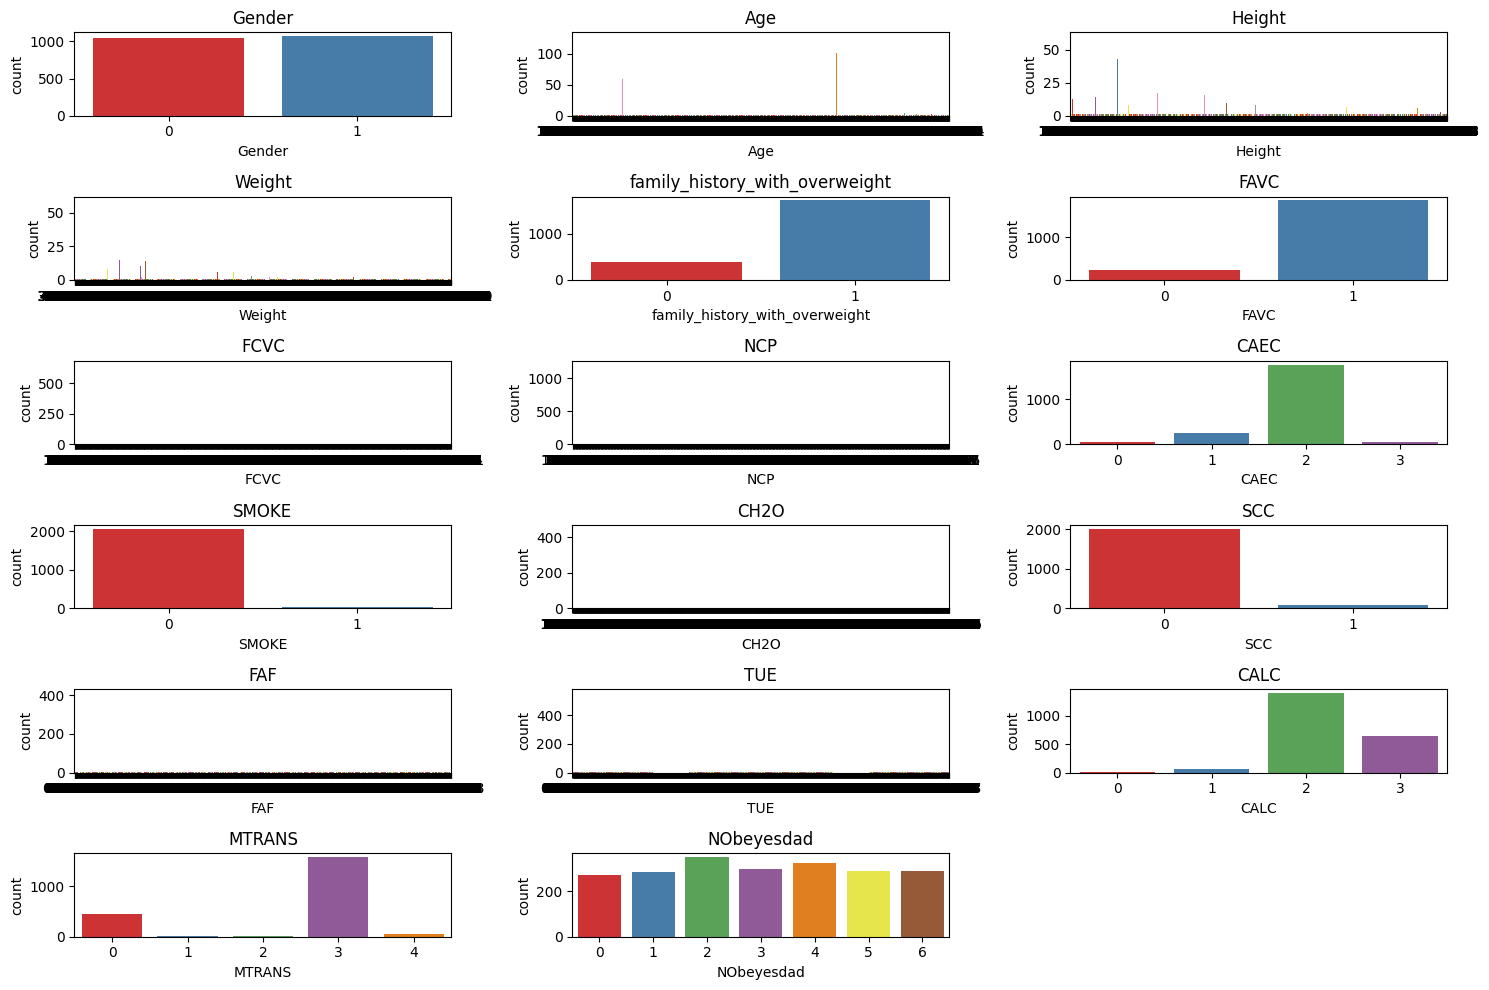

In [183]:
color_palette = sns.color_palette("Set1", len(df.columns))

plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns, 1):
    plt.subplot((len(df.columns)//3)+1, 3, i)
    sns.countplot(data=df, x=column, palette=color_palette)
    plt.title(column)

plt.tight_layout()
plt.show()

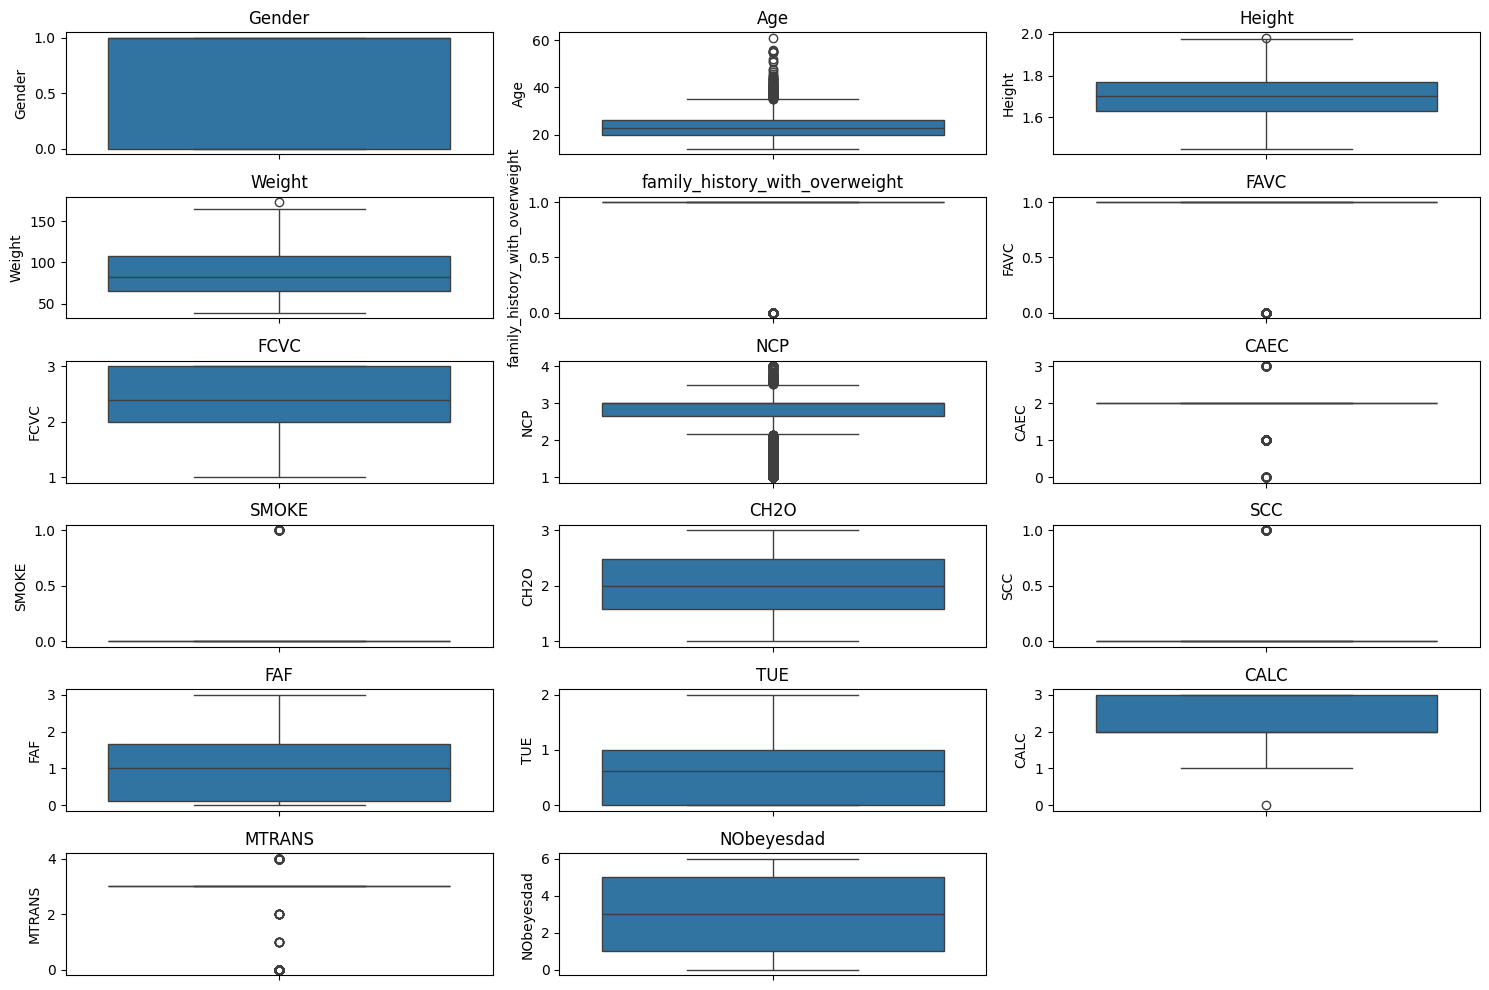

In [184]:
# Select ALL numeric columns (includes newly converted bool + category)
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [187]:
cols = ['Weight', 'Height']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

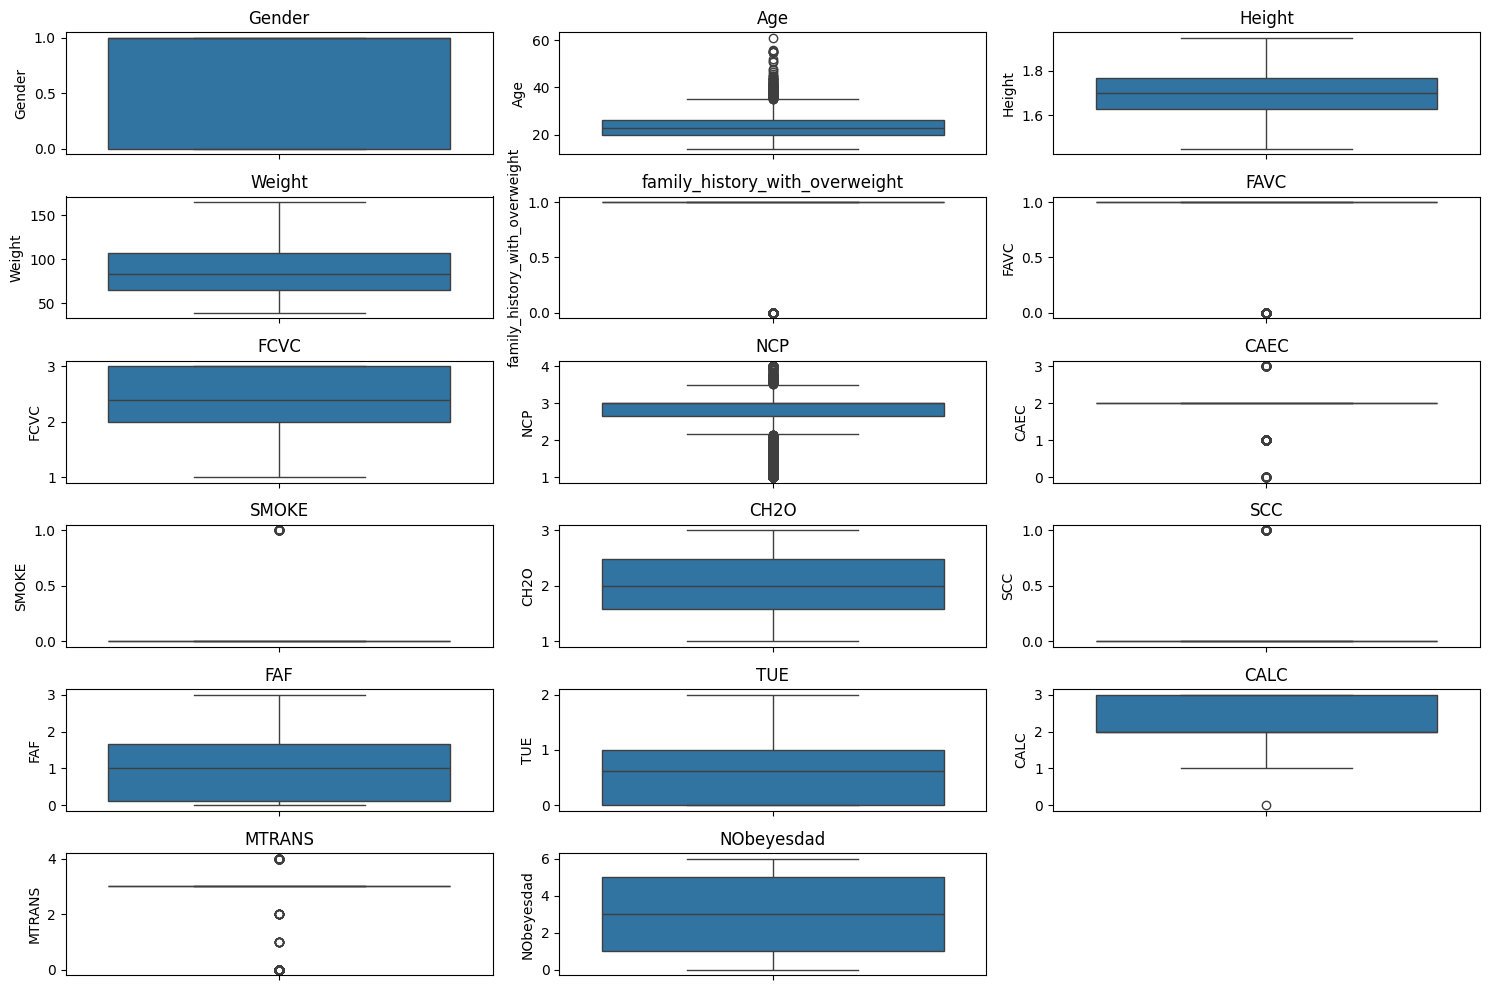

In [188]:
# Select ALL numeric columns (includes newly converted bool + category)
num_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [189]:
df_train = df[num_cols]

## K-Means Clustering

In [190]:
wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_train)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_train, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [509112.73035228485]
silhoutte score for n_clusters = 2 is 0.5633761792221659
wcss score for n_cluster = 3 is [509112.73035228485, 285898.51951990987]
silhoutte score for n_clusters = 3 is 0.495534779370158
wcss score for n_cluster = 4 is [509112.73035228485, 285898.51951990987, 201875.613513063]
silhoutte score for n_clusters = 4 is 0.46657411055784515
wcss score for n_cluster = 5 is [509112.73035228485, 285898.51951990987, 201875.613513063, 163868.6841899989]
silhoutte score for n_clusters = 5 is 0.41884983528759456
wcss score for n_cluster = 6 is [509112.73035228485, 285898.51951990987, 201875.613513063, 163868.6841899989, 130188.33349472217]
silhoutte score for n_clusters = 6 is 0.44573558125204926
wcss score for n_cluster = 7 is [509112.73035228485, 285898.51951990987, 201875.613513063, 163868.6841899989, 130188.33349472217, 104033.8839292812]
silhoutte score for n_clusters = 7 is 0.4309898099496047
wcss score for n_cluster = 8 is [509112.7303522848

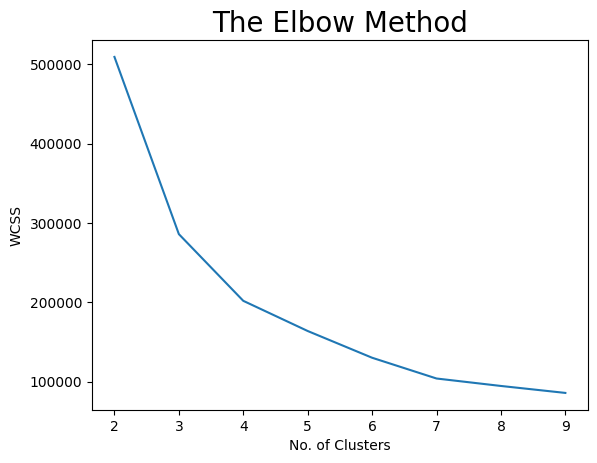

In [191]:
# Visualisasi Elbow Score
plt.plot(range(2, 10), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

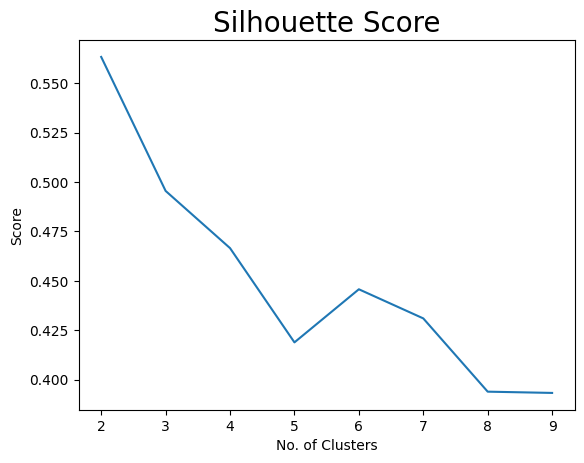

In [192]:
# Visualisasi Silhouette Score
plt.plot(range(2, 10), scores)
plt.title('Silhouette Score', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('Score')
plt.show()

In [193]:
kmeansmodel = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
y_kmeans= kmeansmodel.fit_predict(df_train)

df_train['Cluster'] = y_kmeans

In [194]:
df_train[df_train['Cluster'] == 0].describe()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,Cluster
count,1286.000000,1286.000000,1286.000000,1286.000000,1286.00000,1286.000000,1286.000000,1286.000000,1286.000000,1286.00000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.0
mean,0.444790,23.573199,1.674990,68.842237,0.70451,0.821151,2.322428,2.608619,1.783048,0.01944,1.943098,0.073095,1.071110,0.667667,2.336703,2.291602,2.823484,0.0
std,0.497136,6.967184,0.091013,14.229117,0.45644,0.383375,0.533309,0.903802,0.565183,0.13812,0.609253,0.260393,0.899749,0.653422,0.558770,1.324903,2.365927,0.0
min,0.000000,14.000000,1.450000,39.000000,0.00000,0.000000,1.000000,1.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,19.000000,1.605501,56.276224,0.00000,1.000000,2.000000,2.008204,2.000000,0.00000,1.510309,0.000000,0.130031,0.000000,2.000000,2.000000,1.000000,0.0
50%,0.000000,21.085569,1.675529,70.000000,1.00000,1.000000,2.061422,3.000000,2.000000,0.00000,2.000000,0.000000,1.000000,0.641145,2.000000,3.000000,2.000000,0.0
75%,1.000000,24.261370,1.740000,80.538174,1.00000,1.000000,2.941123,3.000000,2.000000,0.00000,2.197400,0.000000,2.000000,1.000000,3.000000,3.000000,5.000000,0.0
max,1.000000,61.000000,1.930000,91.499683,1.00000,1.000000,3.000000,4.000000,3.000000,1.00000,3.000000,1.000000,3.000000,2.000000,3.000000,4.000000,6.000000,0.0


In [195]:
df_train[df_train['Cluster'] == 1].describe()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,Cluster
count,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.000000,822.0
mean,0.599757,25.486950,1.742552,114.152492,0.993917,0.981752,2.570508,2.804959,1.981752,0.023114,2.107163,0.002433,0.914262,0.641284,2.163017,2.478102,3.317518,1.0
std,0.490246,5.019657,0.080005,13.408302,0.077802,0.133929,0.499067,0.503321,0.187054,0.150358,0.604798,0.049296,0.758995,0.532759,0.419029,1.148587,0.937854,0.0
min,0.000000,17.000000,1.560000,91.495718,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.0
25%,0.000000,21.697106,1.674682,104.790671,1.000000,1.000000,2.031610,3.000000,2.000000,0.000000,1.663950,0.000000,0.112199,0.167402,2.000000,3.000000,3.000000,1.0
50%,1.000000,25.496168,1.752972,111.941263,1.000000,1.000000,2.871453,3.000000,2.000000,0.000000,2.137210,0.000000,0.975904,0.617066,2.000000,3.000000,3.000000,1.0
75%,1.000000,26.947124,1.795956,120.994169,1.000000,1.000000,3.000000,3.000000,2.000000,0.000000,2.627254,0.000000,1.484860,0.927822,2.000000,3.000000,4.000000,1.0
max,1.000000,41.000000,1.947406,165.057269,1.000000,1.000000,3.000000,4.000000,3.000000,1.000000,3.000000,1.000000,3.000000,2.000000,3.000000,4.000000,6.000000,1.0


In [196]:
cluster_summary = df_train.groupby('Cluster').mean()
cluster_summary

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
Cluster,,,,,,,,,,,,,,,,,
0,0.444790,23.573199,1.674990,68.842237,0.704510,0.821151,2.322428,2.608619,1.783048,0.019440,1.943098,0.073095,1.071110,0.667667,2.336703,2.291602,2.823484
1,0.599757,25.486950,1.742552,114.152492,0.993917,0.981752,2.570508,2.804959,1.981752,0.023114,2.107163,0.002433,0.914262,0.641284,2.163017,2.478102,3.317518


## Hierarchical (Agglomerative) Clustering

In [197]:
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'complete', 'average', 'single']
silhouette_scores_linkage = {method: [] for method in linkage_methods}
sse_scores_linkage = {method: [] for method in linkage_methods}

for linkage_method in linkage_methods:
    print('Linkage: ', linkage_method)
    for i in range(2, 10):
        model = AgglomerativeClustering(n_clusters=i, linkage=linkage_method)
        labels = model.fit_predict(df_train)

        score = silhouette_score(df_train, labels)
        silhouette_scores_linkage[linkage_method].append(score)

        sse = 0
        for cluster_id in np.unique(labels):
            cluster_points = df_train.values[labels == cluster_id]
            centroid = cluster_points.mean(axis=0)
            sse += ((cluster_points - centroid) ** 2).sum()
        sse_scores_linkage[linkage_method].append(sse)

        print(f'n_clusters={i} | silhouette={score:.4f} | SSE={sse:.4f}')
    print("\n##########################\n")

Linkage:  ward
n_clusters=2 | silhouette=0.5638 | SSE=510599.0182
n_clusters=3 | silhouette=0.4551 | SSE=314489.9878
n_clusters=4 | silhouette=0.4473 | SSE=227651.5730
n_clusters=5 | silhouette=0.4065 | SSE=178099.1086
n_clusters=6 | silhouette=0.3748 | SSE=148552.1320
n_clusters=7 | silhouette=0.3796 | SSE=120886.7564
n_clusters=8 | silhouette=0.3671 | SSE=107633.0526
n_clusters=9 | silhouette=0.3763 | SSE=97051.7522

##########################

Linkage:  complete
n_clusters=2 | silhouette=0.3903 | SSE=1099040.4066
n_clusters=3 | silhouette=0.3914 | SSE=436758.6173
n_clusters=4 | silhouette=0.4460 | SSE=221039.3888
n_clusters=5 | silhouette=0.4422 | SSE=218609.5979
n_clusters=6 | silhouette=0.4228 | SSE=208405.4053
n_clusters=7 | silhouette=0.4139 | SSE=176299.2568
n_clusters=8 | silhouette=0.4019 | SSE=134196.6985
n_clusters=9 | silhouette=0.3911 | SSE=102609.3832

##########################

Linkage:  average
n_clusters=2 | silhouette=0.5630 | SSE=511019.9984
n_clusters=3 | silhouet

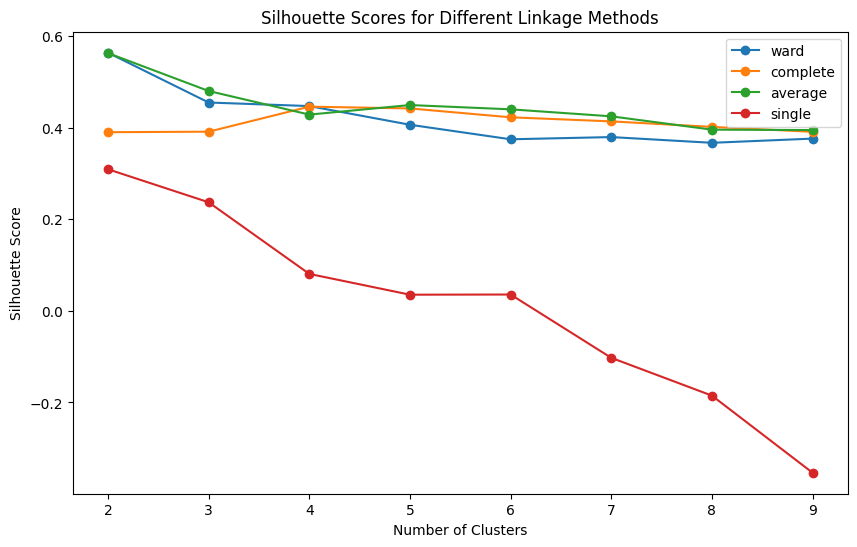

In [198]:
# Visualisasi Silhouette Score - Hierarchical
plt.figure(figsize=(10, 6))
for method, scores in silhouette_scores_linkage.items():
    plt.plot(range(2, 10), scores, marker='o', label=method)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Linkage Methods')
plt.legend()
plt.show()

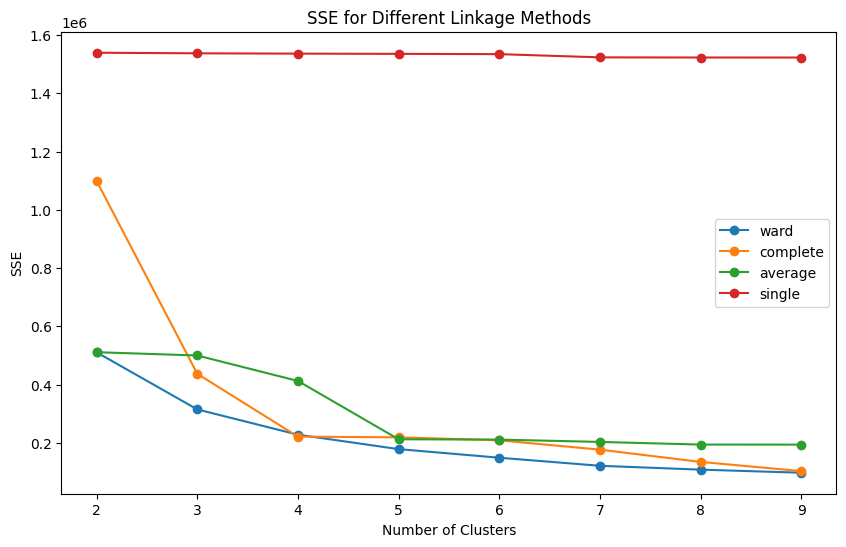

In [199]:
# Visualisasi SSE - Hierarchical
plt.figure(figsize=(10, 6))
for method, sses in sse_scores_linkage.items():
    plt.plot(range(2, 10), sses, marker='o', label=method)
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.title('SSE for Different Linkage Methods')
plt.legend()
plt.show()

In [200]:
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
df_train_with_labels = df_train.copy()
labels = agg_clustering.fit_predict(df_train)
df_train_with_labels['Cluster'] = labels

cluster_summary = df_train_with_labels.groupby('Cluster').mean()
print(cluster_summary)

           Gender        Age    Height      Weight  \
Cluster                                              
0        0.448807  23.642203  1.676347   69.080309   
1        0.595797  25.406904  1.741460  114.498325   

         family_history_with_overweight      FAVC      FCVC       NCP  \
Cluster                                                                 
0                              0.707467  0.822941  2.319107  2.607705   
1                              0.993820  0.981459  2.579828  2.809582   

             CAEC     SMOKE      CH2O       SCC       FAF       TUE      CALC  \
Cluster                                                                         
0        1.784450  0.019246  1.941396  0.072363  1.069279  0.667440  2.333333   
1        1.982695  0.023486  2.112533  0.002472  0.914682  0.641224  2.165637   

           MTRANS  NObeyesdad  
Cluster                        
0        2.285604    2.849115  
1        2.490729    3.284302  


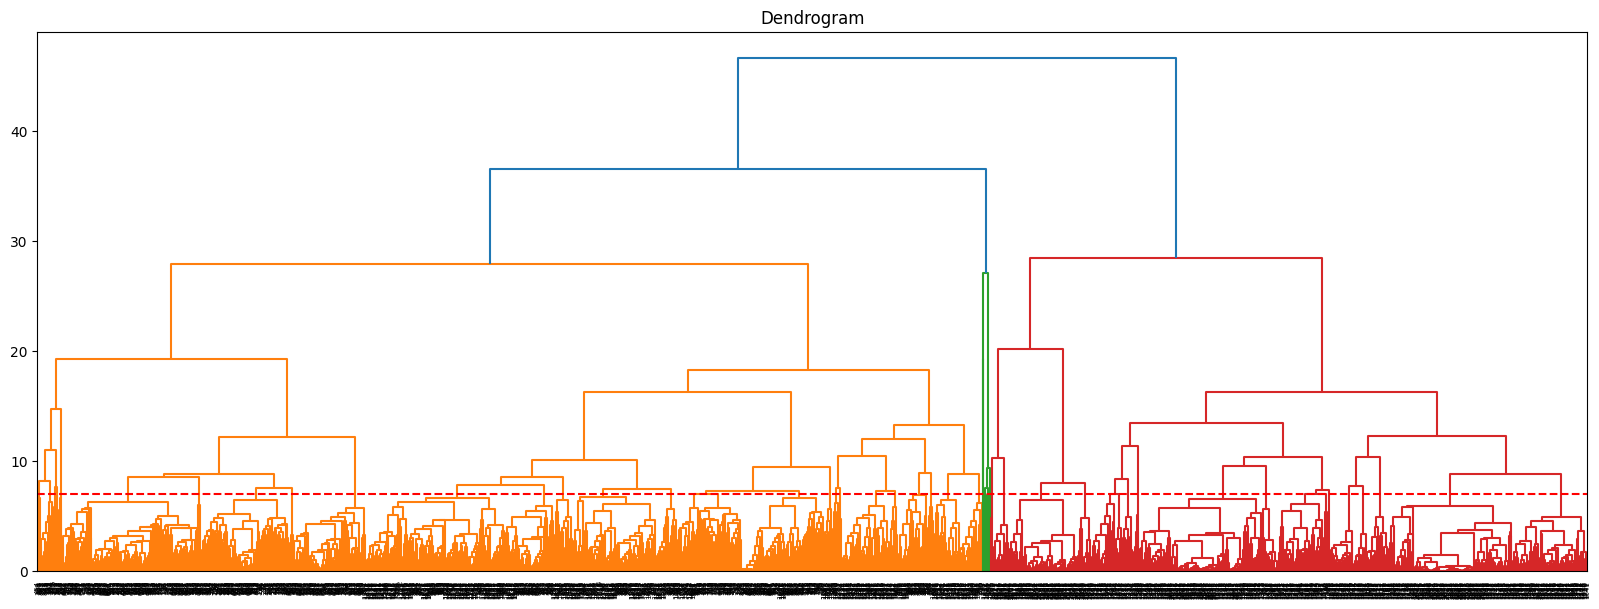

In [201]:
linked = sch.linkage(df_train, method='average')
plt.figure(figsize=(20, 7))
sch.dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.axhline(y=7, color='r', linestyle='--')
plt.title('Dendrogram')
plt.show()

# Selected Features

In [202]:
df = pd.read_csv('./ObesityDataSet_raw_and_data_sinthetic.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [203]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [204]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [205]:
df.columns = df.columns.str.strip()

# Convert True/False boolean columns to 1/0
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# Convert categorical/object columns to numeric codes
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df[cat_cols] = df[cat_cols].apply(lambda col: pd.Categorical(col).codes)

print(df.dtypes)
print(df.head())

Gender                               int8
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight       int8
FAVC                                 int8
FCVC                              float64
NCP                               float64
CAEC                                 int8
SMOKE                                int8
CH2O                              float64
SCC                                  int8
FAF                               float64
TUE                               float64
CALC                                 int8
MTRANS                               int8
NObeyesdad                           int8
dtype: object
   Gender   Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  \
0       0  21.0    1.62    64.0                               1     0   2.0   
1       0  21.0    1.52    56.0                               1     0   3.0   
2       1  23.0    1.80    77.0    

/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/3667412469.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [206]:
selected_columns = ['Weight'] 
df = df[selected_columns]
df

,Weight
0,64.000000
1,56.000000
2,77.000000
3,87.000000
4,89.800000
...,...
2106,131.408528
2107,133.742943
2108,133.689352
2109,133.346641


/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, palette=color_palette)
/var/folders/37/r93cb2cn17n7pbyq09_p_11r0000gn/T/ipykernel_84085/1135554680.py:6: UserWarning: 
The palette list has fewer values (1) than needed (1525) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=column, palette=color_palette)


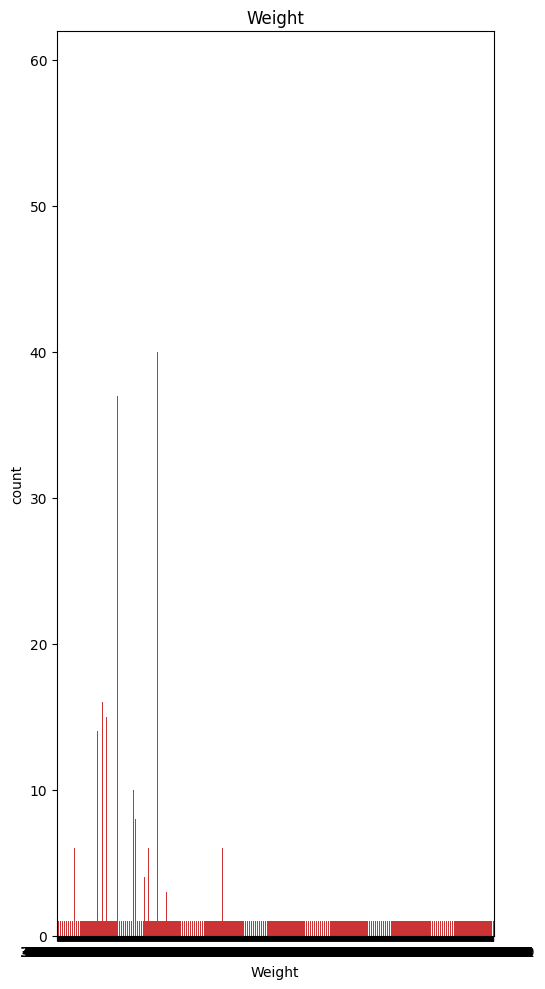

In [207]:
color_palette = sns.color_palette("Set1", len(df.columns))

plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns, 1):
    plt.subplot((len(df.columns)//3)+1, 3, i)
    sns.countplot(data=df, x=column, palette=color_palette)
    plt.title(column)

plt.tight_layout()
plt.show()

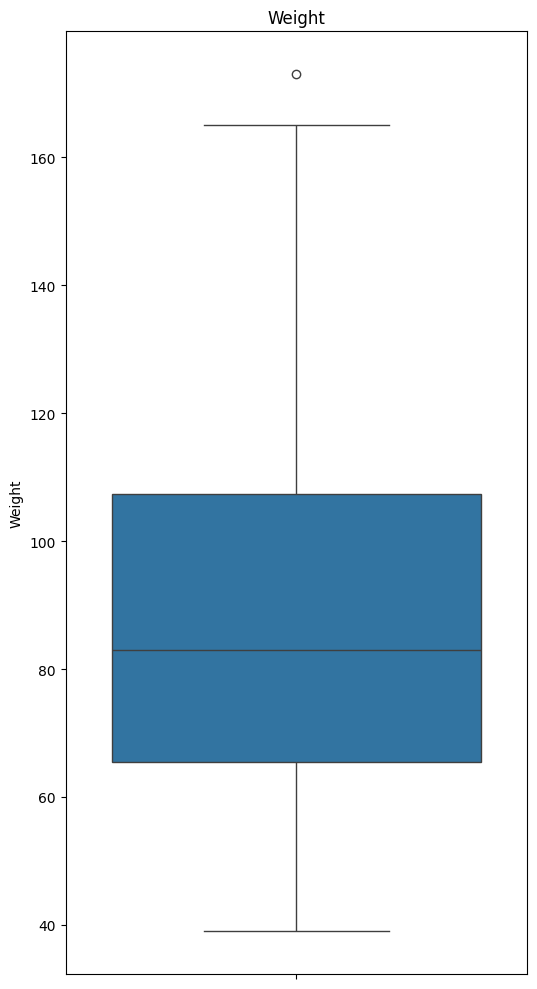

In [208]:
# Select ALL numeric columns (includes newly converted bool + category)
plt.figure(figsize=(15, 10))
for i, col in enumerate(df, 1):
    plt.subplot((len(df.columns) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [209]:
cols = ['Weight']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

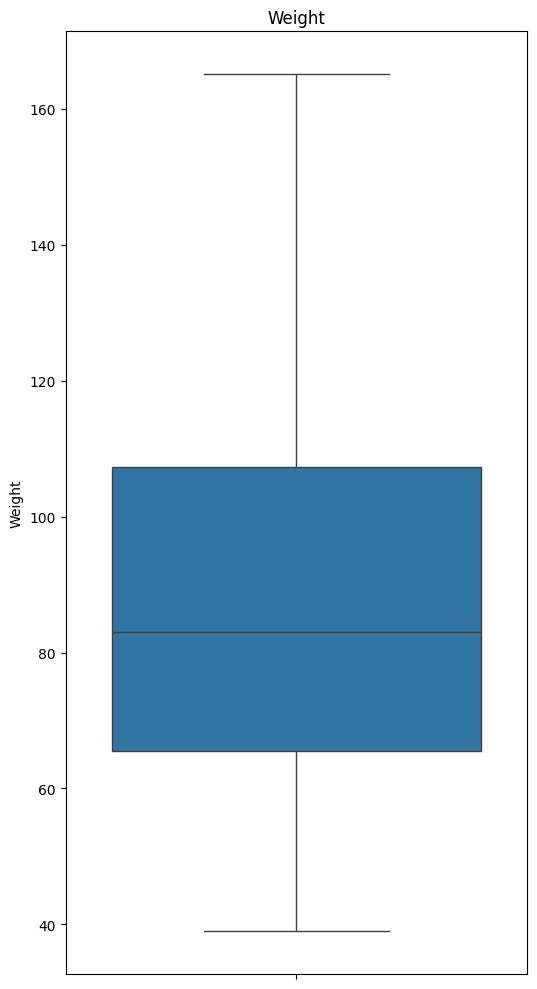

In [210]:
# Select ALL numeric columns (includes newly converted bool + category)
plt.figure(figsize=(15, 10))
for i, col in enumerate(df, 1):
    plt.subplot((len(df.columns) // 3) + 1, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

## K-Means Clustering

In [211]:
df_train = df

wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_train)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_train, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [407930.6427797008]
silhoutte score for n_clusters = 2 is 0.625654346444445
wcss score for n_cluster = 3 is [407930.6427797008, 195021.34535134735]
silhoutte score for n_clusters = 3 is 0.5974524341634941
wcss score for n_cluster = 4 is [407930.6427797008, 195021.34535134735, 111422.9458671885]
silhoutte score for n_clusters = 4 is 0.5887044350212762
wcss score for n_cluster = 5 is [407930.6427797008, 195021.34535134735, 111422.9458671885, 77340.10518928166]
silhoutte score for n_clusters = 5 is 0.5775937817485416
wcss score for n_cluster = 6 is [407930.6427797008, 195021.34535134735, 111422.9458671885, 77340.10518928166, 51097.06677143114]
silhoutte score for n_clusters = 6 is 0.5837804065509969
wcss score for n_cluster = 7 is [407930.6427797008, 195021.34535134735, 111422.9458671885, 77340.10518928166, 51097.06677143114, 40031.38398566068]
silhoutte score for n_clusters = 7 is 0.5647405432894875
wcss score for n_cluster = 8 is [407930.6427797008, 19502

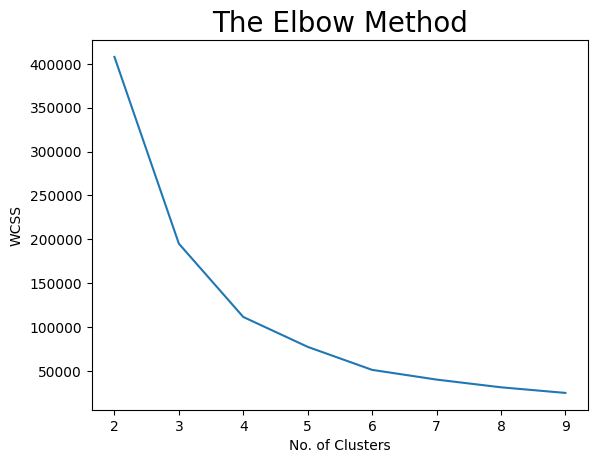

In [212]:
# Visualisasi Elbow Score
plt.plot(range(2, 10), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

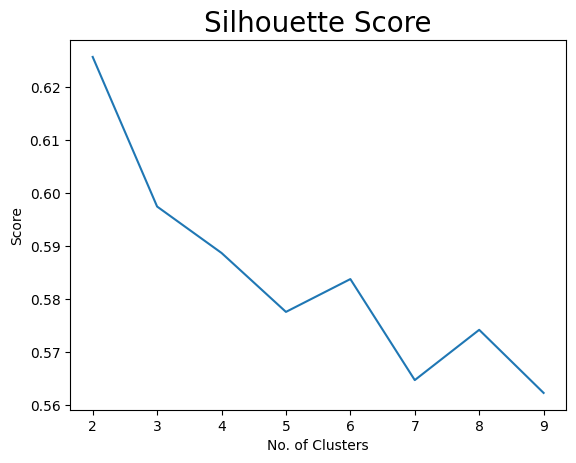

In [213]:
# Visualisasi Silhouette Score
plt.plot(range(2, 10), scores)
plt.title('Silhouette Score', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('Score')
plt.show()

In [214]:
kmeansmodel = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
y_kmeans= kmeansmodel.fit_predict(df_train)

df_train['Cluster'] = y_kmeans

In [215]:
df_train[df_train['Cluster'] == 0].describe()

,Weight,Cluster
count,823.000000,823.0
mean,114.201162,0.0
std,13.384033,0.0
min,91.630257,0.0
25%,104.799160,0.0
50%,111.945588,0.0
75%,120.996328,0.0
max,165.057269,0.0


In [216]:
df_train[df_train['Cluster'] == 1].describe()

,Weight,Cluster
count,1287.000000,1287.0
mean,68.859839,1.0
std,14.237593,0.0
min,39.000000,1.0
25%,56.286489,1.0
50%,70.000000,1.0
75%,80.546033,1.0
max,91.499683,1.0


In [217]:
cluster_summary = df_train.groupby('Cluster').mean()
cluster_summary

,Weight
Cluster,
0,114.201162
1,68.859839


In [218]:
trace0 = go.Scatter(
    x=df_train[df_train['Cluster'] == 0]['Weight'],
    y=[0]*len(df_train[df_train['Cluster'] == 0]),  # all points at y=0
    mode='markers',
    marker=dict(size=10, color='red', opacity=0.8),
    name='Cluster 0'
)

# Trace for Cluster 1
trace1 = go.Scatter(
    x=df_train[df_train['Cluster'] == 1]['Weight'],
    y=[0]*len(df_train[df_train['Cluster'] == 1]),
    mode='markers',
    marker=dict(size=10, color='blue', opacity=0.8),
    name='Cluster 1'
)

# Centroids (y set to 0 as well)
centroids = go.Scatter(
    x=kmeansmodel.cluster_centers_[:, 0],  # Weight
    y=[0]*len(kmeansmodel.cluster_centers_[:, 0]),  # y=0
    mode='markers',
    marker=dict(size=15, color='black', symbol='x', opacity=1),
    name='Centroids'
)

# Layout
layout = go.Layout(
    title='KMeans Clustering (Weight Only)',
    xaxis_title='Weight',
    yaxis=dict(visible=False),  # hide y-axis entirely
    showlegend=True
)

# Plot
fig = go.Figure(data=[trace0, trace1, centroids], layout=layout)
fig.show()

## Hierarchical (Agglomerative) Clustering

In [219]:
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'complete', 'average', 'single']
silhouette_scores_linkage = {method: [] for method in linkage_methods}
sse_scores_linkage = {method: [] for method in linkage_methods}

for linkage_method in linkage_methods:
    print('Linkage: ', linkage_method)
    for i in range(2, 10):
        model = AgglomerativeClustering(n_clusters=i, linkage=linkage_method)
        labels = model.fit_predict(df_train)

        score = silhouette_score(df_train, labels)
        silhouette_scores_linkage[linkage_method].append(score)

        sse = 0
        for cluster_id in np.unique(labels):
            cluster_points = df_train.values[labels == cluster_id]
            centroid = cluster_points.mean(axis=0)
            sse += ((cluster_points - centroid) ** 2).sum()
        sse_scores_linkage[linkage_method].append(sse)

        print(f'n_clusters={i} | silhouette={score:.4f} | SSE={sse:.4f}')
    print("\n##########################\n")

Linkage:  ward
n_clusters=2 | silhouette=0.6258 | SSE=407930.6428
n_clusters=3 | silhouette=0.5138 | SSE=236520.2549
n_clusters=4 | silhouette=0.5258 | SSE=145745.3531
n_clusters=5 | silhouette=0.5346 | SSE=90336.8866
n_clusters=6 | silhouette=0.5442 | SSE=58132.2956
n_clusters=7 | silhouette=0.5459 | SSE=42620.9490
n_clusters=8 | silhouette=0.5480 | SSE=34301.0458
n_clusters=9 | silhouette=0.5570 | SSE=27211.0630

##########################

Linkage:  complete
n_clusters=2 | silhouette=0.6016 | SSE=453100.6736
n_clusters=3 | silhouette=0.5569 | SSE=419759.7683
n_clusters=4 | silhouette=0.5662 | SSE=164547.4671
n_clusters=5 | silhouette=0.5569 | SSE=116145.7029
n_clusters=6 | silhouette=0.5267 | SSE=74335.2677
n_clusters=7 | silhouette=0.5141 | SSE=52494.2231
n_clusters=8 | silhouette=0.4866 | SSE=50200.4294
n_clusters=9 | silhouette=0.4867 | SSE=49911.5692

##########################

Linkage:  average
n_clusters=2 | silhouette=0.6258 | SSE=407930.6428
n_clusters=3 | silhouette=0.5612

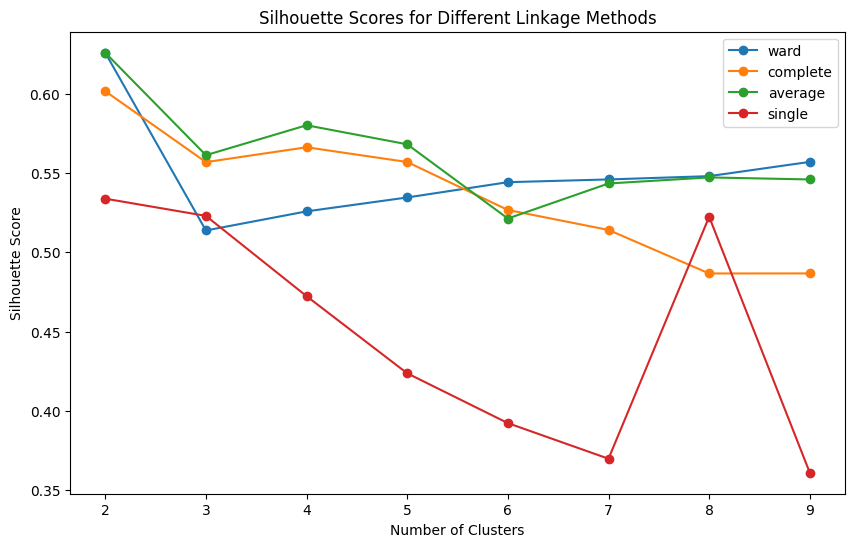

In [220]:
# Visualisasi Silhouette Score - Hierarchical
plt.figure(figsize=(10, 6))
for method, scores in silhouette_scores_linkage.items():
    plt.plot(range(2, 10), scores, marker='o', label=method)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Linkage Methods')
plt.legend()
plt.show()

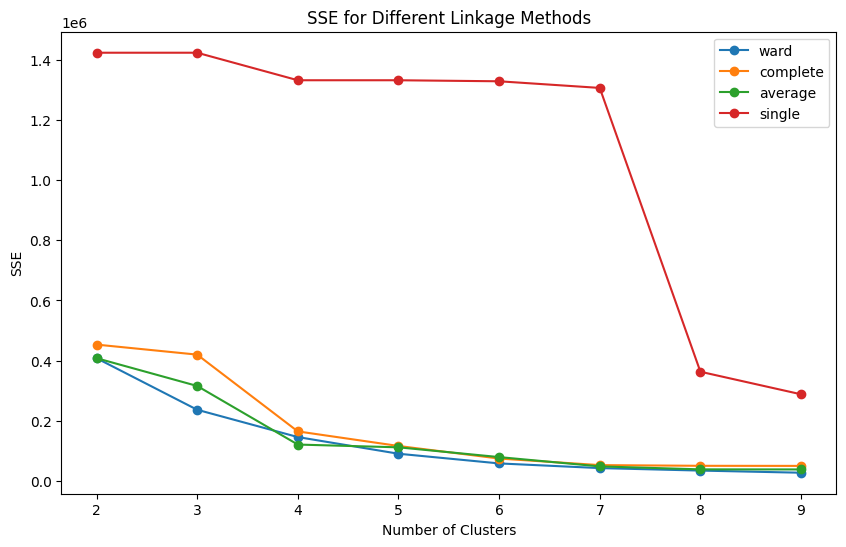

In [221]:
# Visualisasi SSE - Hierarchical
plt.figure(figsize=(10, 6))
for method, sses in sse_scores_linkage.items():
    plt.plot(range(2, 10), sses, marker='o', label=method)
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.title('SSE for Different Linkage Methods')
plt.legend()
plt.show()

In [222]:
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
df_train_with_labels = df_train.copy()
labels = agg_clustering.fit_predict(df_train)
df_train_with_labels['Cluster'] = labels

cluster_summary = df_train_with_labels.groupby('Cluster').mean()
print(cluster_summary)

             Weight
Cluster            
0         68.859839
1        114.201162


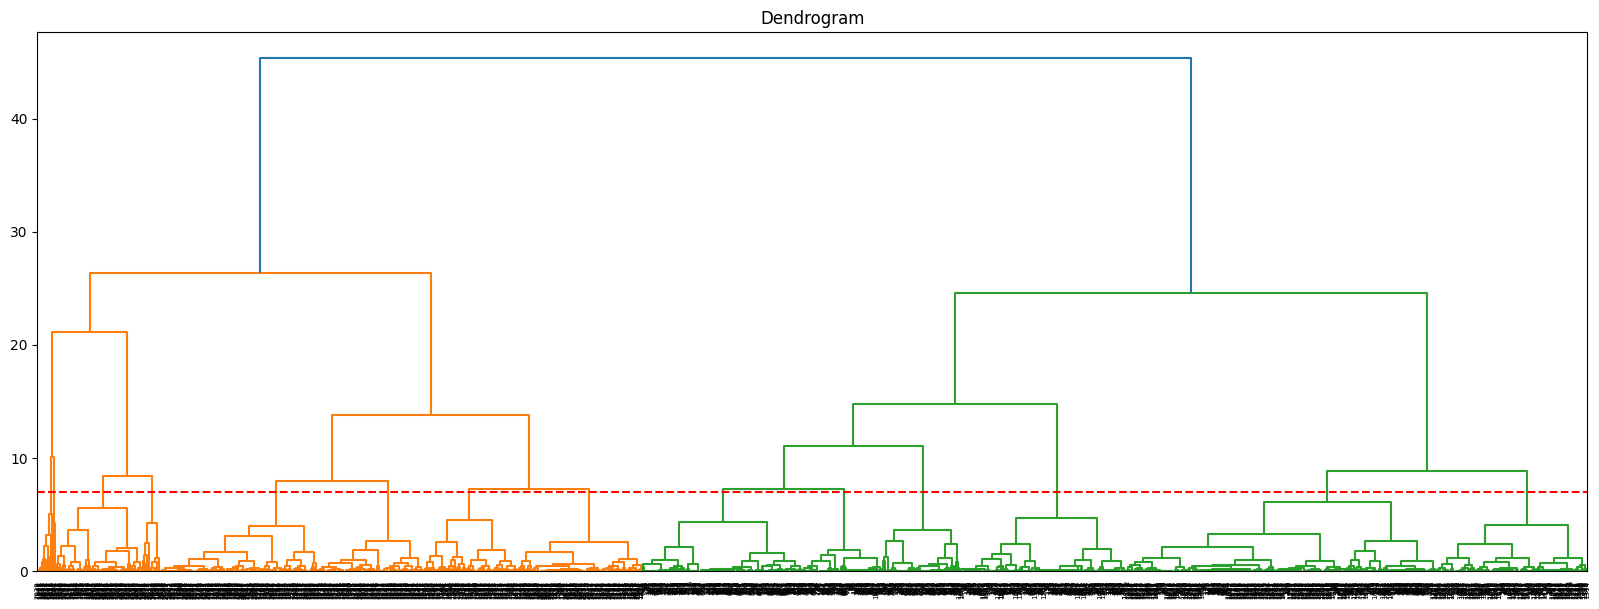

In [223]:
linked = sch.linkage(df_train, method='average')
plt.figure(figsize=(20, 7))
sch.dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.axhline(y=7, color='r', linestyle='--')
plt.title('Dendrogram')
plt.show()

## Analisis

### Selected Features: Clustering Berbasis Fitur Weight

Pada bagian ini, clustering dilakukan hanya menggunakan fitur **Weight (Berat Badan)** sebagai hasil dari proses seleksi fitur sebelumnya.

#### K-Means Clustering
- Jumlah cluster optimal: **2** (Silhouette Score: **0.6256** | WCSS/SSE: **407,930.64**)
- **Cluster 0** (Berat): 823 sampel — rata-rata berat ≈ 114.2 kg
- **Cluster 1** (Ringan): 1287 sampel — rata-rata berat ≈ 68.9 kg

#### Hierarchical (Agglomerative) Clustering
- Metode linkage terbaik: **Ward**, cluster optimal: **2** (Silhouette Score: **0.6258** | SSE: **407,930.64**)
- **Cluster 0** (Ringan): rata-rata berat ≈ 68.9 kg
- **Cluster 1** (Berat): rata-rata berat ≈ 114.2 kg

### Perbandingan: K-Means vs. Hierarchical Clustering (Fitur: Weight)

| Metode | Cluster | Silhouette Score | SSE/WCSS |
|---|---|---|---|
| K-Means | 2 | **0.6256** | **407,930.64** |
| Hierarchical (Ward) | 2 | **0.6258** | **407,930.64** |

### Kesimpulan

Clustering yang hanya menggunakan satu fitur, yaitu Weight, menghasilkan silhouette score yang lebih tinggi dibandingkan ketika menggunakan semua fitur numerik. Hal ini kemungkinan terjadi karena fitur lain seperti usia, tinggi badan, dan kebiasaan makan tidak terlalu membantu dalam membedakan kelompok data. Justru, ketika semua fitur digunakan, batas antar cluster menjadi kurang jelas.

Metode K-Means maupun Hierarchical Clustering menunjukkan hasil yang serupa: data ini secara alami paling cocok dibagi menjadi dua kelompok. Kelompok pertama terdiri dari individu dengan rata-rata berat badan sekitar 68,9 kg, sedangkan kelompok kedua memiliki rata-rata sekitar 114,2 kg. Nilai silhouette score dari kedua metode juga hampir sama (0,6256 dan 0,6258), yang menunjukkan bahwa hasil clustering cukup stabil dan konsisten.

Dari sisi SSE, K-Means dan Hierarchical (Ward) menghasilkan nilai SSE yang identik yaitu **407,930.64** untuk 2 cluster. Hal ini menunjukkan bahwa kedua metode berhasil menemukan pembagian cluster yang sama secara kuantitatif. K-Means secara langsung mengoptimalkan SSE dalam proses iterasinya, sementara Hierarchical (Ward) menggunakan kriteria minimisasi variance antar cluster yang secara tidak langsung juga mengoptimalkan SSE sehingga hasilnya konvergen ke solusi yang sama.

Kelompok pertama kemungkinan berada pada rentang normal hingga overweight, sedangkan kelompok kedua sudah lebih mendekati kategori obesitas. Hal ini menunjukkan bahwa berat badan merupakan fitur yang paling berpengaruh dalam dataset ini, sehingga bisa menjadi titik awal yang baik untuk analisis lebih lanjut.